In [36]:
import brian2 as b2 # type: ignore
import matplotlib.pyplot as plt # type: ignore
%matplotlib inline

#### **Effects of the membrane time constant**

Let's analyze how does the firing rate of a leaky integrate-and-fire neuron driven by Poisson spiking neurons change depending on its membrane time constant.

In [37]:
b2.start_scope()
b2.BrianLogger.suppress_name('unused_brian_object')

num_inputs = 100
input_rate = 10 * b2.Hz 
weight = 0.1 
tau_range = b2.linspace(1, 10, 30) * b2.ms

output_rates = []

for tau in tau_range:
    poisson = b2.PoissonGroup(num_inputs, rates = input_rate)
    eqs = ''' dv/dt = -v/tau : 1 '''
    post = b2.NeuronGroup(1, eqs, threshold = 'v>1', reset = 'v=0', method = 'exact')
    syn = b2.Synapses(poisson, post, on_pre = 'v += weight')
    syn.connect()

    M = b2.SpikeMonitor(post)
    b2.run(1 * b2.second)
    output_rates.append(M.num_spikes / b2.second)

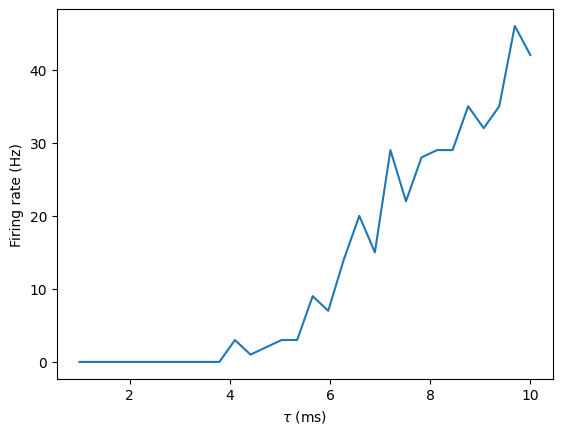

In [38]:
b2.plot(tau_range / b2.ms, output_rates)
b2.xlabel(r'$\tau$ (ms)')
b2.ylabel('Firing rate (Hz)');

We can improve the performance of the simulation by setting up the network just once. We store a copy of the state of the network before the loop, and restore it at the beginning of each iteration.

In [39]:
b2.start_scope()
b2.BrianLogger.suppress_name('unused_brian_object')

num_inputs = 100
input_rate = 10 * b2.Hz 
weight = 0.1
tau_range = b2.linspace(1, 10, 30) * b2.ms

output_rates = []

poisson = b2.PoissonGroup(num_inputs, rates = input_rate)
eqs = ''' dv/dt = -v/tau : 1 '''
group = b2.NeuronGroup(1, eqs, threshold = 'v>1', reset = 'v=0', method = 'exact')
syn = b2.Synapses(poisson, group, on_pre = 'v += weight')
syn.connect()

M = b2.SpikeMonitor(group)
b2.store() # Store current state of the network 

for tau in tau_range:
    b2.restore() # Restore the original state of the network
    b2.run(1 * b2.second)
    output_rates.append(M.num_spikes / b2.second)

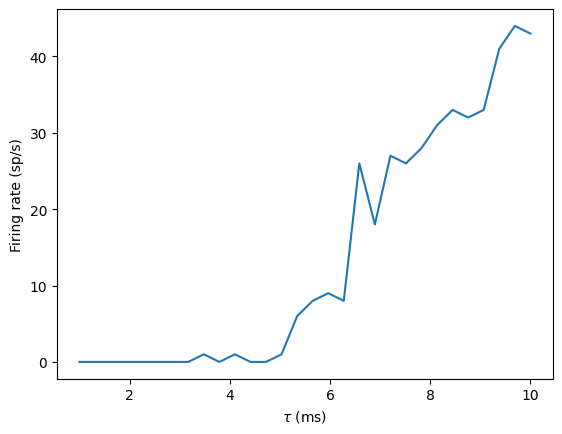

In [40]:
b2.plot(tau_range / b2.ms, output_rates)
b2.xlabel(r'$\tau$ (ms)')
b2.ylabel('Firing rate (sp/s)');

It is also possible to store the Poisson spikes to avoid randomness and assess in a cleaner way the effect of the membrane time constant. We do this by running just the Poisson group once, recording its spikes, and then creating a new ``SpikeGeneratorGroup`` that will output those recorded spikes each time.

In [41]:
b2.start_scope()
b2.BrianLogger.suppress_name('unused_brian_object')

num_inputs = 100
input_rate = 10 * b2.Hz 
weight = 0.1
tau_range = b2.linspace(1, 10, 30) * b2.ms

output_rates = []

poisson = b2.PoissonGroup(num_inputs, rates = input_rate)
MP = b2.SpikeMonitor(poisson)

# We need a Network object to not include these elements later 
net = b2.Network(poisson, MP)
net.run(1 * b2.second)

# We take a copy of the Poisson spikes 
spikes_i = MP.i
spikes_t = MP.t
SGG = b2.SpikeGeneratorGroup(num_inputs, spikes_i, spikes_t)

eqs = ''' dv/dt = -v/tau : 1 '''
group = b2.NeuronGroup(1, eqs, threshold = 'v>1', reset = 'v=0', method = 'exact')
syn = b2.Synapses(SGG, group, on_pre = 'v += weight')
syn.connect()
M = b2.SpikeMonitor(group)

# Store the current state of the network
net = b2.Network(SGG, group, syn, M)
net.store()

tau_values = []
isi_mu = []
isi_std = []

for tau in tau_range:
    net.restore()
    net.run(1 * b2.second)
    output_rates.append(M.num_spikes / b2.second)
    
    # Interspike intervales
    trains = M.spike_trains()
    train = b2.diff(trains[0])
    if len(train) > 1:
        isi_mu.append(b2.mean(train))
        isi_std.append(b2.std(train))
        tau_values.append(tau)

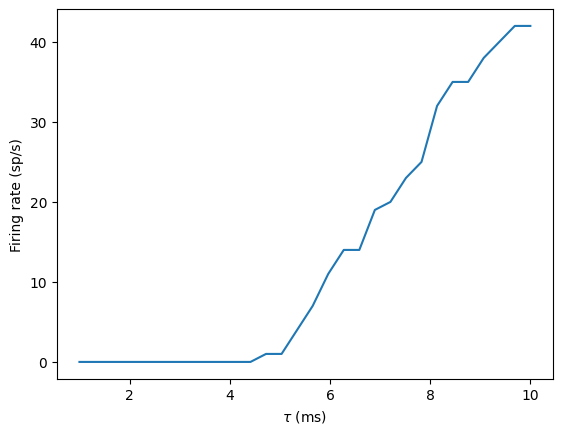

In [42]:
b2.plot(tau_range / b2.ms, output_rates)
b2.xlabel(r'$\tau$ (ms)')
b2.ylabel('Firing rate (sp/s)');

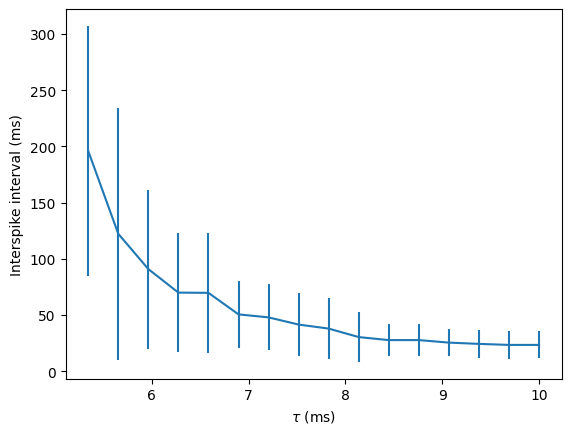

In [43]:
b2.errorbar(tau_values / b2.ms, isi_mu / b2.ms, yerr = isi_std / b2.ms)
b2.xlabel(r'$\tau$ (ms)')
b2.ylabel('Interspike interval (ms)');

#### **Changing things during a simulation**
The main idea is to change the input current injected into a Hodgkin-Huxley neuron.

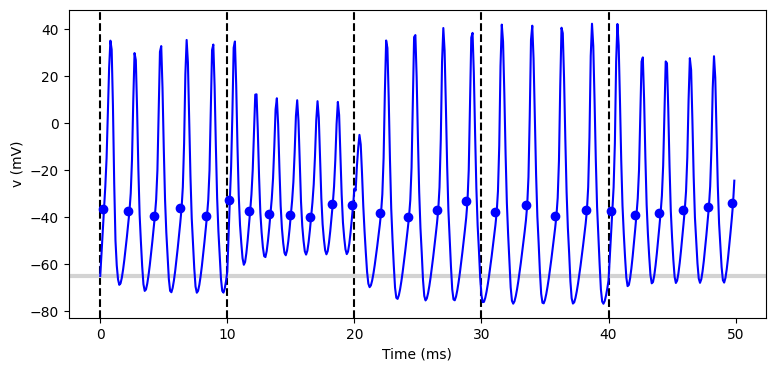

In [44]:
b2.start_scope()
b2.BrianLogger.suppress_name('unused_brian_object')

# Model parameters
area = 20000 * b2.umetre**2
Cm = 1 * b2.ufarad * b2.cm**-2 * area
gl = 5e-5 * b2.siemens * b2.cm**-2 * area
El = -65 * b2.mV
EK = -90 * b2.mV
ENa = 50 * b2.mV
g_na = 100 * b2.msiemens * b2.cm**-2 * area
g_kd = 30 * b2.msiemens * b2.cm**-2 * area
VT = -63 * b2.mV

# Hodgkin-Huxley model
eqs_hh = '''
dv/dt = (gl*(El-v) - g_na*(m*m*m)*h*(v-ENa) - g_kd*(n*n*n*n)*(v-EK) + I)/Cm : volt
dm/dt = 0.32*(mV**-1)*(13.*mV-v+VT)/
        (exp((13.*mV-v+VT)/(4.*mV))-1.)/ms*(1-m)-0.28*(mV**-1)*(v-VT-40.*mV)/
        (exp((v-VT-40.*mV)/(5.*mV))-1.)/ms*m : 1
dn/dt = 0.032*(mV**-1)*(15.*mV-v+VT)/
        (exp((15.*mV-v+VT)/(5.*mV))-1.)/ms*(1.-n)-.5*exp((10.*mV-v+VT)/(40.*mV))/ms*n : 1
dh/dt = 0.128*exp((17.*mV-v+VT)/(18.*mV))/ms*(1.-h)-4./(1+exp((40.*mV-v+VT)/(5.*mV)))/ms*h : 1    
I : amp '''

group = b2.NeuronGroup(1, eqs_hh, threshold = 'v > -40*mV', refractory = 'v > -40*mV', method='exponential_euler')
group.v = El

# Monitors
state_mon = b2.StateMonitor(group, 'v', record = True)
spike_mon = b2.SpikeMonitor(group, variables = 'v')

# Simulation and figure
b2.figure(figsize = (9, 4))
for l in range(5):
    group.I = b2.rand() * 50 * b2.nA
    b2.run(10 * b2.ms)
    b2.axvline(l * 10, ls = '--', c = 'k')
b2.axhline(El / b2.mV, ls = '-', c = 'lightgray', lw = 3)
b2.plot(state_mon.t / b2.ms, state_mon.v[0] / b2.mV, '-b')
b2.plot(spike_mon.t / b2.ms, spike_mon.v / b2.mV, 'ob')
b2.xlabel('Time (ms)')
b2.ylabel('v (mV)');

In the code above, we used a loop over multiple runs to achieve this. That's fine, but it's not the most efficient way to do it because each time we call ``run`` we have to do a lot of initialisation work that slows everything down. It also won't work as well with the more efficient standalone mode of Brian.

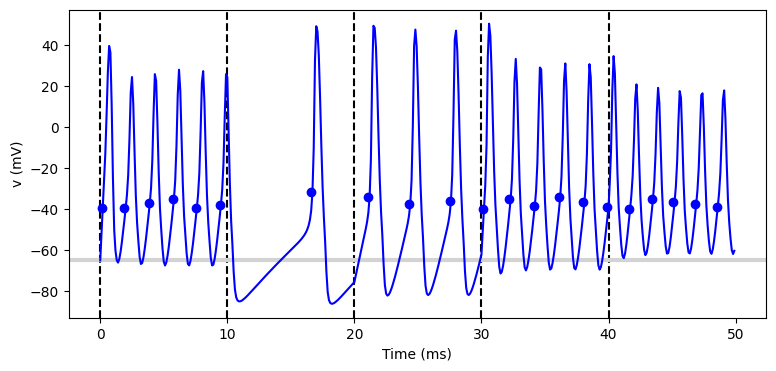

In [45]:
b2.start_scope()
b2.BrianLogger.suppress_name('unused_brian_object')

group = b2.NeuronGroup(1, eqs_hh, threshold = 'v > -40*mV', refractory = 'v > -40*mV', method='exponential_euler')
group.v = El

# Monitors
state_mon = b2.StateMonitor(group, 'v', record = True)
spike_mon = b2.SpikeMonitor(group, variables = 'v')

group.run_regularly('I = rand()*50*nA', dt = 10 * b2.ms)
b2.run(50 * b2.ms)

# Figure
b2.figure(figsize = (9, 4))
for l in range(5):
    b2.axvline(l * 10, ls = '--', c = 'k')
b2.axhline(El / b2.mV, ls = '-', c = 'lightgray', lw = 3)
b2.plot(state_mon.t / b2.ms, state_mon.v[0] / b2.mV, '-b')
b2.plot(spike_mon.t / b2.ms, spike_mon.v / b2.mV, 'ob')
b2.xlabel('Time (ms)')
b2.ylabel('v (mV)');

We've replaced the loop that had multiple ``run`` calls with a ``run_regularly``. This makes the specified block of code run every ``dt = 10*ms``. The ``run_regularly`` lets you run code specific to a single `NeuronGroup`, but sometimes you might need more flexibility. For this, you can use `network_operation` which lets you run arbitrary Python code (but won't work with the standalone mode).

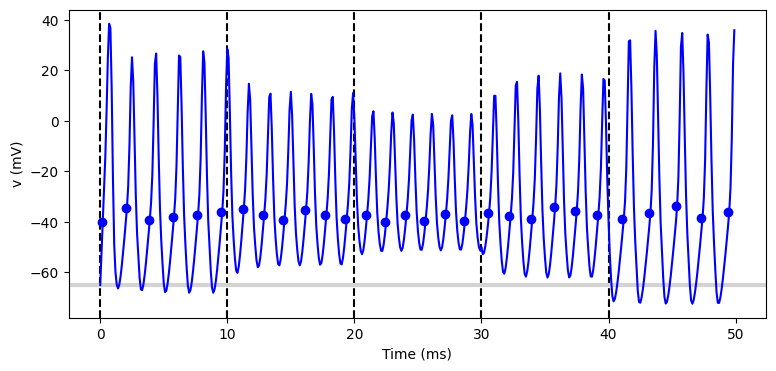

In [46]:
b2.start_scope()
b2.BrianLogger.suppress_name('unused_brian_object')

group = b2.NeuronGroup(1, eqs_hh, threshold = 'v > -40*mV', refractory = 'v > -40*mV', method='exponential_euler')
group.v = El

# Monitors
state_mon = b2.StateMonitor(group, 'v', record = True)
spike_mon = b2.SpikeMonitor(group, variables = 'v')

# Replace the loop with a network operation
@b2.network_operation(dt = 10 * b2.ms)
def change_current():
    group.I = b2.rand() * 50 * b2.nA

b2.run(50 * b2.ms)  

# Figure
b2.figure(figsize = (9, 4))
for l in range(5):
    b2.axvline(l * 10, ls = '--', c = 'k')
b2.axhline(El / b2.mV, ls = '-', c = 'lightgray', lw = 3)
b2.plot(state_mon.t / b2.ms, state_mon.v[0] / b2.mV, '-b')
b2.plot(spike_mon.t / b2.ms, spike_mon.v / b2.mV, 'ob')
b2.xlabel('Time (ms)')
b2.ylabel('v (mV)');

- Simulating more than one neuron

The procedure ``run_regularly`` is interpreted as being run separately for each neuron, and because I is a parameter, it can be different for each one of them. We can fix this by making I into a *shared* variable, meaning it has the same value for each neuron.

In [51]:
b2.start_scope()
b2.BrianLogger.suppress_name('unused_brian_object')

N = 3

eqs_hh_shared = '''
dv/dt = (gl*(El-v) - g_na*(m*m*m)*h*(v-ENa) - g_kd*(n*n*n*n)*(v-EK) + I)/C : volt
dm/dt = 0.32*(mV**-1)*(13.*mV-v+VT)/
        (exp((13.*mV-v+VT)/(4.*mV))-1.)/ms*(1-m)-0.28*(mV**-1)*(v-VT-40.*mV)/
        (exp((v-VT-40.*mV)/(5.*mV))-1.)/ms*m : 1
dn/dt = 0.032*(mV**-1)*(15.*mV-v+VT)/
        (exp((15.*mV-v+VT)/(5.*mV))-1.)/ms*(1.-n)-.5*exp((10.*mV-v+VT)/(40.*mV))/ms*n : 1
dh/dt = 0.128*exp((17.*mV-v+VT)/(18.*mV))/ms*(1.-h)-4./(1+exp((40.*mV-v+VT)/(5.*mV)))/ms*h : 1
I : amp (shared) # everything is the same except we've added this shared
C : farad '''

group = b2.NeuronGroup(N, eqs_hh_shared, threshold = 'v > -40*mV', refractory = 'v > -40*mV', method = 'exponential_euler')
group.v = El
group.C = b2.array([0.6, 1, 1.4]) * b2.ufarad * b2.cm**-2 * area


state_mon = b2.StateMonitor(group, 'v', record = True)
group.run_regularly('I = rand()*50*nA', dt = 10 * b2.ms)
b2.run(50 * b2.ms)

Note that each neuron has a different membrane capacitance (C).

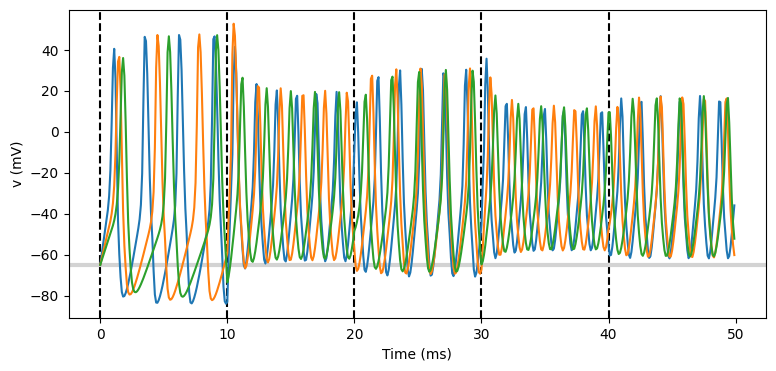

In [52]:
b2.figure(figsize = (9, 4))
for l in range(5):
    b2.axvline(l * 10, ls = '--', c = 'k')
b2.axhline(El / b2.mV, ls = '-', c = 'lightgray', lw = 3)
b2.plot(state_mon.t / b2.ms, state_mon.v.T / b2.mV, '-')
b2.xlabel('Time (ms)')
b2.ylabel('v (mV)');

#### **Adding a sinusoidal input**


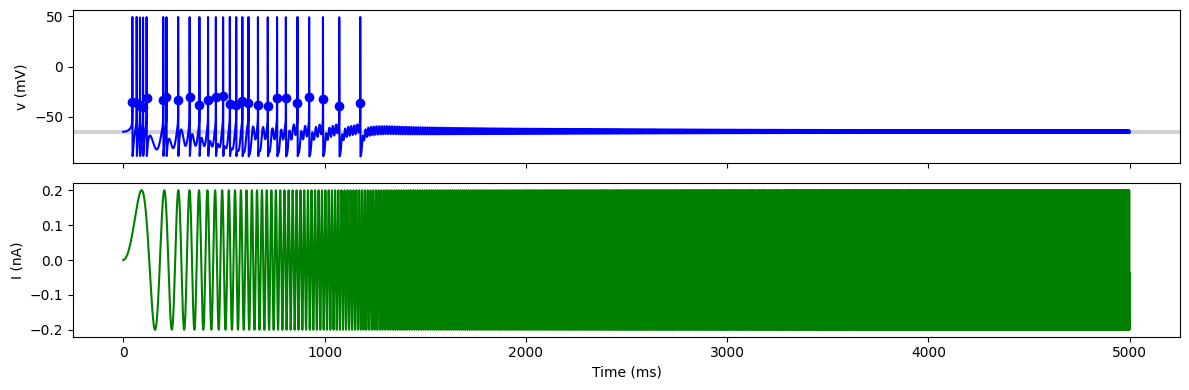

In [ ]:
import brian2 as b2
import matplotlib.pyplot as plt

b2.start_scope()
b2.BrianLogger.suppress_name('unused_brian_object')

# Model parameters
area = 20000 * b2.umetre**2
Cm = 0.5 * b2.ufarad * b2.cm**-2 * area
gl = 5e-5 * b2.siemens * b2.cm**-2 * area
El = -65 * b2.mV
EK = -90 * b2.mV
ENa = 50 * b2.mV
g_na = 100 * b2.msiemens * b2.cm**-2 * area
g_kd = 30 * b2.msiemens * b2.cm**-2 * area
VT = -63 * b2.mV

# Zap Current Parameters
A = 0.2 * b2.nA       # Amplitude of the zap current
f_max = 300 * b2.Hz    # Maximum frequency reached at t_max
t_max = 5000 * b2.ms  # Duration of the simulation

# Hodgkin-Huxley model
# The current I is a time-dependent equation
eqs_hh = '''
dv/dt = (gl*(El-v) - g_na*(m*m*m)*h*(v-ENa) - g_kd*(n*n*n*n)*(v-EK) + I)/Cm : volt
dm/dt = 0.32*(mV**-1)*(13.*mV-v+VT)/ \
        (exp((13.*mV-v+VT)/(4.*mV))-1.)/ms*(1-m)-0.28*(mV**-1)*(v-VT-40.*mV)/ \
        (exp((v-VT-40.*mV)/(5.*mV))-1.)/ms*m : 1
dn/dt = 0.032*(mV**-1)*(15.*mV-v+VT)/ \
        (exp((15.*mV-v+VT)/(5.*mV))-1.)/ms*(1.-n)-.5*exp((10.*mV-v+VT)/(40.*mV))/ms*n : 1
dh/dt = 0.128*exp((17.*mV-v+VT)/(18.*mV))/ms*(1.-h)-4./(1+exp((40.*mV-v+VT)/(5.*mV)))/ms*h : 1    
I = A * sin(pi*f_max*t**2/t_max) : amp '''

group = b2.NeuronGroup(1, eqs_hh, threshold = 'v > -40*mV', refractory = 'v > -40*mV', method = 'exponential_euler')
group.v = El

# Monitors 
state_mon = b2.StateMonitor(group, ['v', 'I'], record = True)
spike_mon = b2.SpikeMonitor(group, variables = 'v')

b2.run(t_max)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (12, 4), sharex = True)
# Plot Voltage
ax1.axhline(El / b2.mV, ls = '-', c = 'lightgray', lw = 3)
ax1.plot(state_mon.t / b2.ms, state_mon.v[0] / b2.mV, '-b')
ax1.plot(spike_mon.t / b2.ms, spike_mon.v / b2.mV, 'ob')
ax1.set_ylabel('v (mV)')
# Plot Current
ax2.plot(state_mon.t / b2.ms, state_mon.I[0] / b2.nA, '-g')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('I (nA)')

plt.tight_layout()
plt.show()

Finally we will see the effect of the membrane capacitance (which determines de membrane time constant) on the frequency-dependent neuron response.

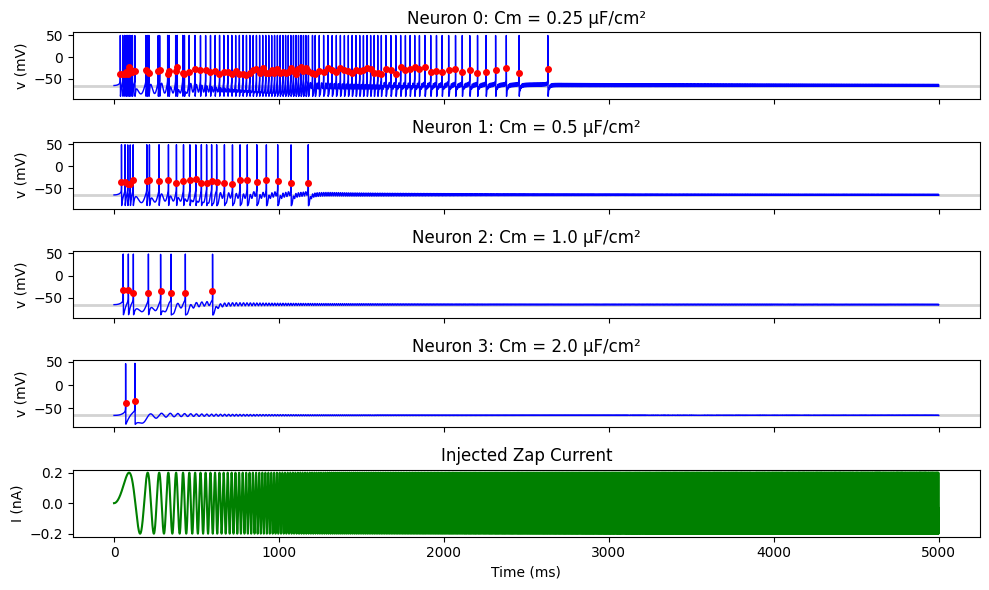

In [80]:
b2.start_scope()
b2.BrianLogger.suppress_name('unused_brian_object')

# Model parameters 
area = 20000 * b2.umetre**2
gl = 5e-5 * b2.siemens * b2.cm**-2 * area
El = -65 * b2.mV
EK = -90 * b2.mV
ENa = 50 * b2.mV
g_na = 100 * b2.msiemens * b2.cm**-2 * area
g_kd = 30 * b2.msiemens * b2.cm**-2 * area
VT = -63 * b2.mV

# Capacitance value
C_multipliers = b2.array([0.25, 0.5, 1.0, 2.0])
N_neurons = len(C_multipliers)

# Zap Current Parameters
A = 0.2 * b2.nA       
f_max = 300 * b2.Hz    
t_max = 5000 * b2.ms  

# Hodgkin-Huxley model
eqs_hh = '''
dv/dt = (gl*(El-v) - g_na*(m*m*m)*h*(v-ENa) - g_kd*(n*n*n*n)*(v-EK) + I)/C_var : volt
dm/dt = 0.32*(mV**-1)*(13.*mV-v+VT)/ \
        (exp((13.*mV-v+VT)/(4.*mV))-1.)/ms*(1-m)-0.28*(mV**-1)*(v-VT-40.*mV)/ \
        (exp((v-VT-40.*mV)/(5.*mV))-1.)/ms*m : 1
dn/dt = 0.032*(mV**-1)*(15.*mV-v+VT)/ \
        (exp((15.*mV-v+VT)/(5.*mV))-1.)/ms*(1.-n)-.5*exp((10.*mV-v+VT)/(40.*mV))/ms*n : 1
dh/dt = 0.128*exp((17.*mV-v+VT)/(18.*mV))/ms*(1.-h)-4./(1+exp((40.*mV-v+VT)/(5.*mV)))/ms*h : 1    
I = A * sin(pi*f_max*t**2/t_max) : amp 
C_var : farad '''

# Create a group of N_neurons
group = b2.NeuronGroup(N_neurons, eqs_hh, threshold='v > -40*mV', refractory='v > -40*mV', method='exponential_euler')
group.v = El
group.C_var  = C_multipliers * b2.ufarad * b2.cm**-2 * area

# Monitors 
state_mon = b2.StateMonitor(group, ['v', 'I'], record=True)
spike_mon = b2.SpikeMonitor(group, variables='v')

b2.run(t_max)

fig, axes = plt.subplots(N_neurons + 1, 1, figsize=(10, 1.2 * (N_neurons + 1)), sharex=True)
for i in range(N_neurons):
    ax = axes[i]
    ax.axhline(El / b2.mV, ls='-', c='lightgray', lw=2)
    ax.plot(state_mon.t / b2.ms, state_mon.v[i] / b2.mV, '-b', lw=1)
    
    spike_times = spike_mon.t[spike_mon.i == i]
    spike_v = spike_mon.v[spike_mon.i == i]
    ax.plot(spike_times / b2.ms, spike_v / b2.mV, 'or', markersize=4)
    
    ax.set_ylabel('v (mV)')
    ax.set_title(f'Neuron {i}: Cm = {C_multipliers[i]} µF/cm²')

ax_I = axes[-1]
ax_I.plot(state_mon.t / b2.ms, state_mon.I[0] / b2.nA, '-g')
ax_I.set_xlabel('Time (ms)')
ax_I.set_ylabel('I (nA)')
ax_I.set_title('Injected Zap Current')

plt.tight_layout()
plt.show()